In [ ]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

warnings.filterwarnings("ignore", category=DeprecationWarning)


import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.decomposition import FastICA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, r2_score, cohen_kappa_score, root_mean_squared_error, median_absolute_error, explained_variance_score
from pmdarima.arima import auto_arima
from joblib import Parallel, delayed
import warnings
from scipy.stats import entropy
from scipy.fft import fft
import numpy as np
import datetime
warnings.filterwarnings('ignore', category=FutureWarning)

In [ ]:
df = pd.read_csv(os.path.join(os.path.dirname(__file__), '..', 'data', 'id3_prices.csv'), index_col=0, parse_dates=True)

<Axes: title={'center': 'Day Ahead Prices'}>

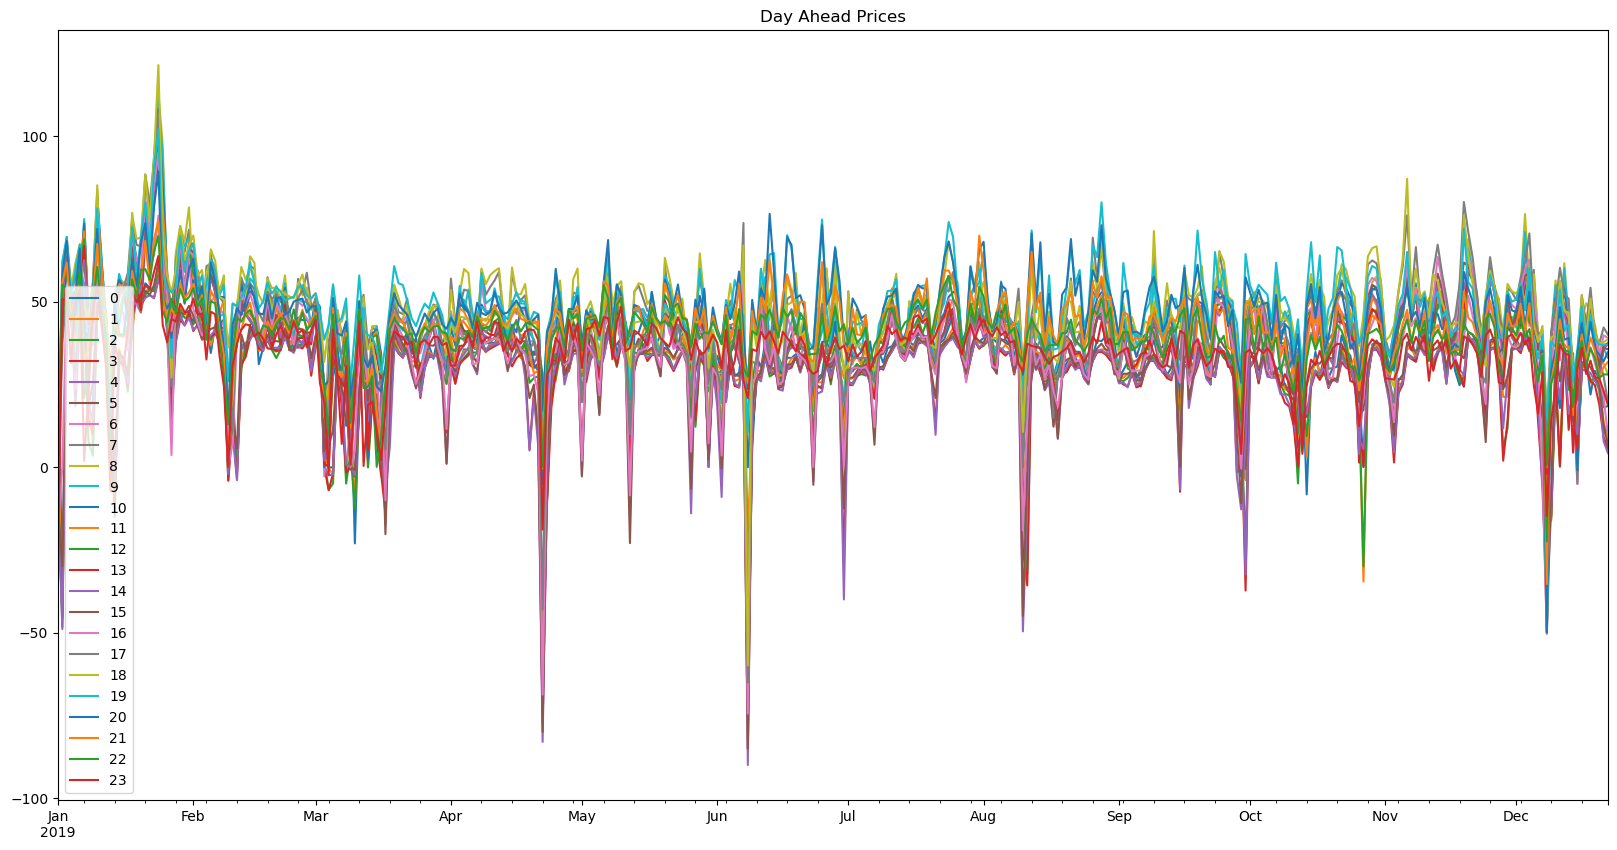

In [ ]:
# 2 year rolling window
window = 356
df_pred = pd.DataFrame(columns=df.columns)
ica_list = []

i = int(356 * 0)

df_window = df.iloc[i:i + window]

df_window.plot(subplots=False, legend=True, figsize=(20, 10), title="Day Ahead Prices")

In [ ]:
standardize = True
if standardize:
    sc = StandardScaler().fit(df_window)
    df_scaled = sc.transform(df_window)
else:
    df_scaled = df_window  # Use smoothed data directly for ICA

ica = FastICA(fun="exp", max_iter=200, algorithm="deflation").fit(df_scaled)
df_ica = pd.DataFrame(ica.transform(df_scaled), index=df_window.index, columns=[f"ica_{j}" for j in range(df_scaled.shape[1])])

df_pred_ica = pd.DataFrame()

# predict in ica latent space
for j in range(df_ica.shape[1]):
    # Fit ARIMA model
    df_pred_ica[j] = auto_arima(df_ica.iloc[:, j], suppress_warnings=True, error_action='ignore') \
        .fit(df_ica.iloc[:, j]) \
            .predict(n_periods=1)

if standardize:
    pred_values = sc.inverse_transform(ica.inverse_transform(df_pred_ica))
else:
    pred_values = ica.inverse_transform(df_pred_ica)
print("finished window", i, "of", len(df) - window)
df_results = pd.DataFrame(pred_values, index=df_pred_ica.index)

finished window 0 of 2048


In [ ]:
def spectral_entropy(signal):
    """Compute spectral entropy of a signal"""
    # Compute power spectral density
    fft_vals = fft(signal)
    psd = np.abs(fft_vals) ** 2
    psd = psd[:len(psd)//2]  # Take only positive frequencies
    
    # Remove DC component (freq=0)
    psd = psd[1:]
    
    # Normalize to get probability distribution
    psd_norm = psd / np.sum(psd)
    
    # Avoid log(0) by adding small epsilon
    psd_norm = psd_norm[psd_norm > 0]
    
    # Compute entropy
    return entropy(psd_norm)

# Compute spectral entropy for each ICA component
entropies = []
for col in df_ica.columns:
    se = spectral_entropy(df_ica[col].values)
    entropies.append((col, se))

# Sort by entropy (lowest first = lowest complexity)
entropies.sort(key=lambda x: x[1])

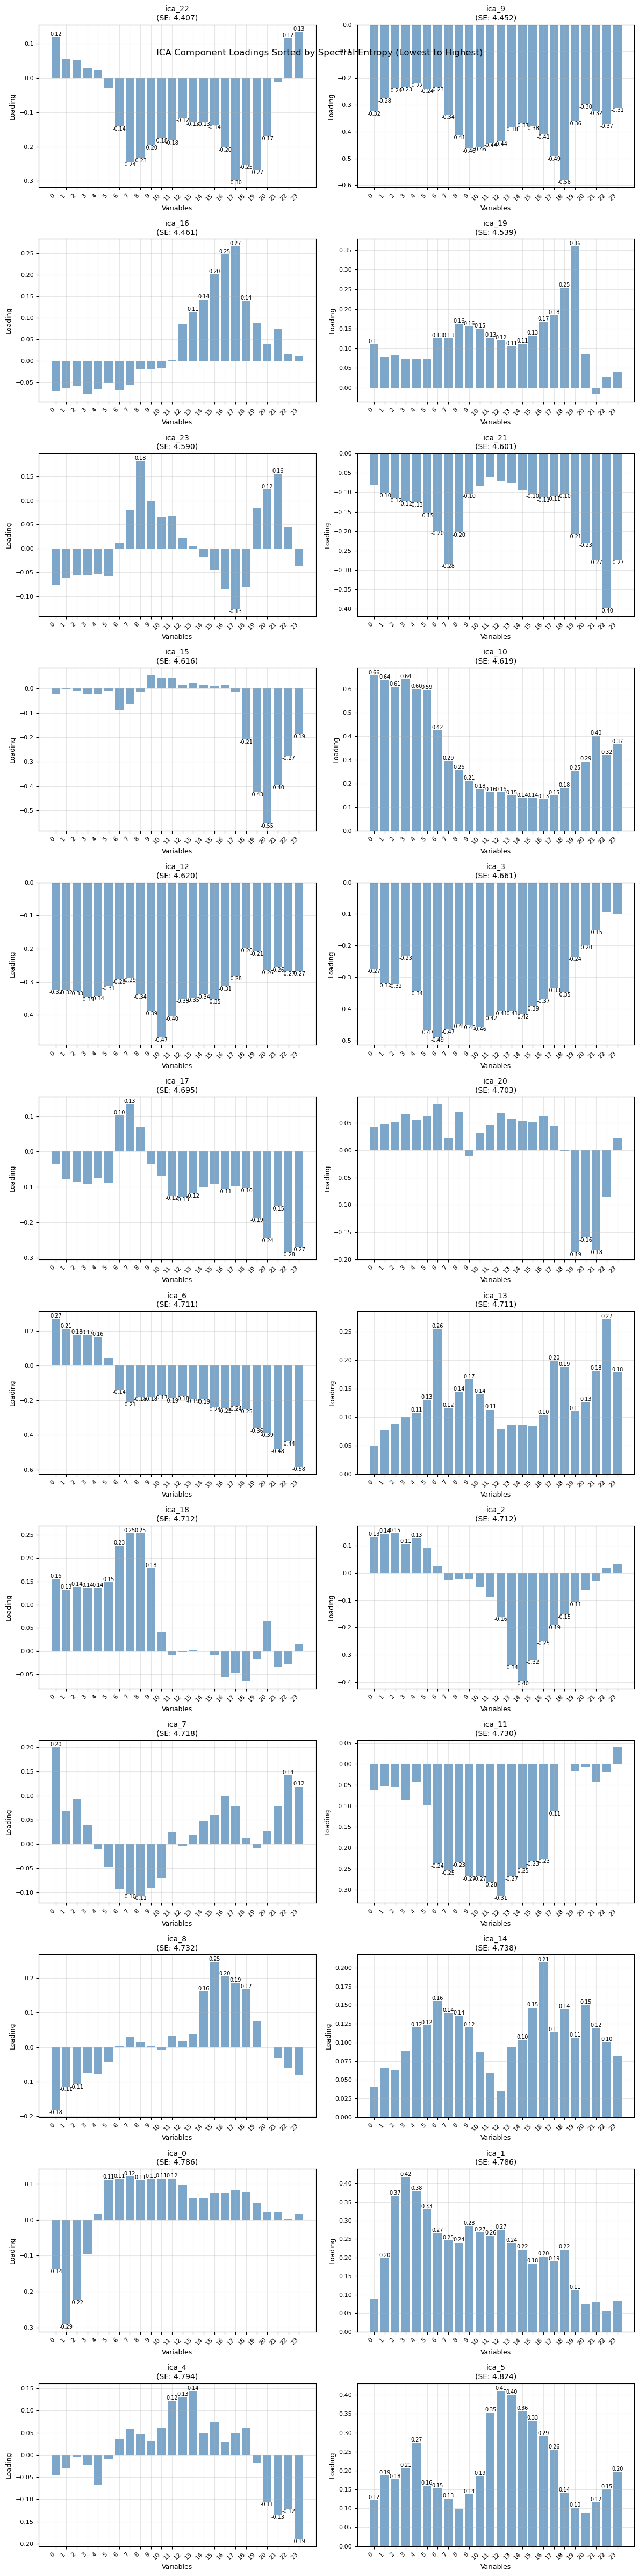

In [ ]:
# Plot ICA component loadings (mixing matrix) sorted by spectral entropy
n_components = len(entropies)
n_cols = 2
n_rows = (n_components + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)
axes = axes.ravel()

for i in range(n_components):
    component_name = entropies[i][0]
    component_idx = int(component_name.split('_')[1])  # Extract component index
    entropy_val = entropies[i][1]
    loadings = ica.mixing_[:, component_idx]
    
    bars = axes[i].bar(range(len(loadings)), loadings, color='steelblue', alpha=0.7)
    axes[i].set_title(f"{component_name}\n(SE: {entropy_val:.3f})", fontsize=10)
    axes[i].set_xlabel("Variables", fontsize=9)
    axes[i].set_ylabel("Loading", fontsize=9)
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(labelsize=8)
    
    # Add country names as x-tick labels if available
    if hasattr(df_window, 'columns'):
        axes[i].set_xticks(range(len(loadings)))
        axes[i].set_xticklabels(df_window.columns, rotation=45, ha='right', fontsize=8)
    
    # Add value labels on bars (only for significant values)
    for j, bar in enumerate(bars):
        height = bar.get_height()
        if abs(height) > 0.1:  # Only show labels for significant loadings
            axes[i].text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.2f}', ha='center', va='bottom' if height >= 0 else 'top',
                        fontsize=7)

# Hide unused subplots
for i in range(n_components, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.suptitle("ICA Component Loadings Sorted by Spectral Entropy (Lowest to Highest)", y=0.98, fontsize=12)
plt.show()

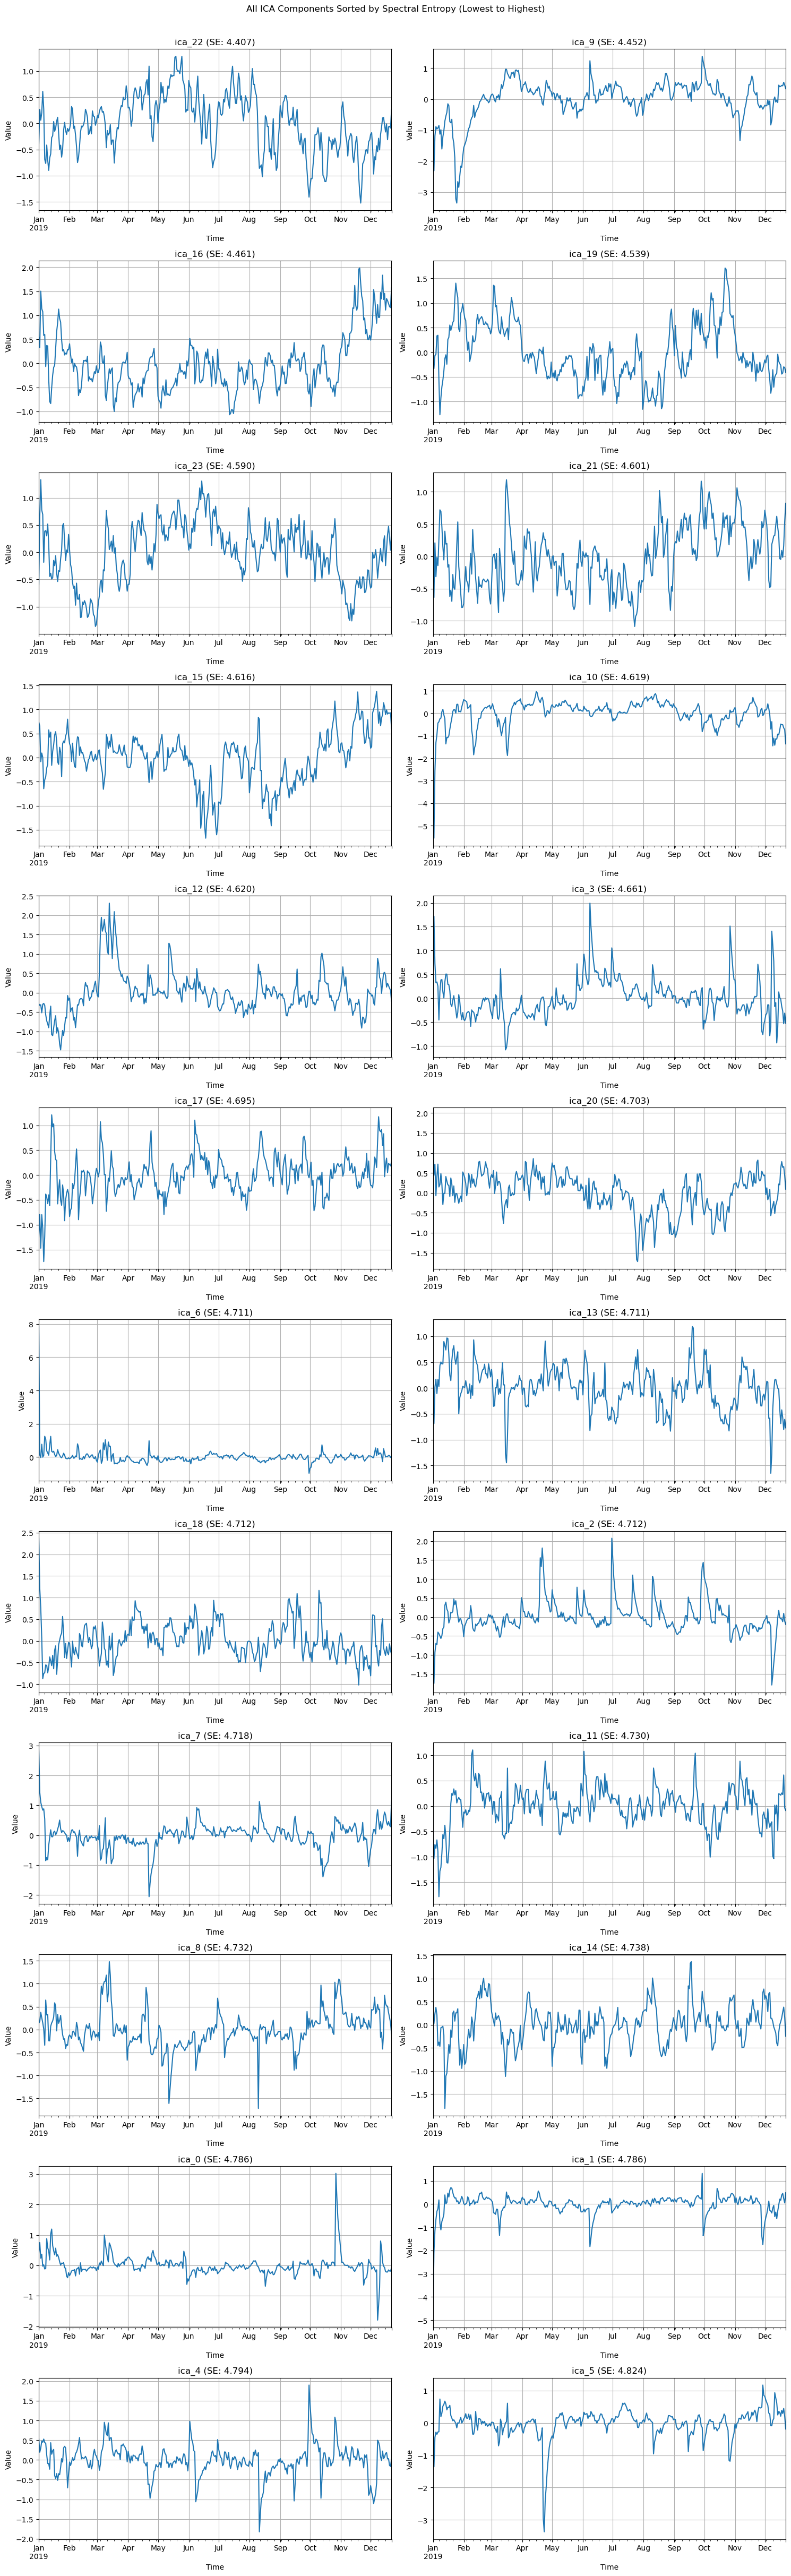

Spectral Entropy Rankings (lowest to highest complexity):
 1. ica_22: 4.4067
 2. ica_9: 4.4525
 3. ica_16: 4.4611
 4. ica_19: 4.5389
 5. ica_23: 4.5896
 6. ica_21: 4.6012
 7. ica_15: 4.6156
 8. ica_10: 4.6189
 9. ica_12: 4.6200
10. ica_3: 4.6615
11. ica_17: 4.6952
12. ica_20: 4.7025
13. ica_6: 4.7113
14. ica_13: 4.7115
15. ica_18: 4.7118
16. ica_2: 4.7123
17. ica_7: 4.7184
18. ica_11: 4.7300
19. ica_8: 4.7316
20. ica_14: 4.7376
21. ica_0: 4.7856
22. ica_1: 4.7859
23. ica_4: 4.7944
24. ica_5: 4.8237


In [ ]:
# Plot ALL components sorted by spectral entropy
n_components = len(entropies)
n_cols = 2
n_rows = (n_components + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)
axes = axes.ravel()

for i in range(n_components):
    component_name = entropies[i][0]
    entropy_val = entropies[i][1]
    
    df_ica[component_name].ewm(span=7).mean().plot(ax=axes[i])
    axes[i].grid(True)
    axes[i].set_title(f"{component_name} (SE: {entropy_val:.3f})")
    axes[i].set_xlabel("Time")
    axes[i].set_ylabel("Value")

# Hide unused subplots
for i in range(n_components, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.suptitle("All ICA Components Sorted by Spectral Entropy (Lowest to Highest)", y=1.01)
plt.show()

# Print all entropy values
print("Spectral Entropy Rankings (lowest to highest complexity):")
for i, (comp, ent) in enumerate(entropies):
    print(f"{i+1:2d}. {comp}: {ent:.4f}")

In [ ]:
# interpretable components
# e.g. a components loadings weight for (peak) daytime usages (morning and evening)
# the price curve for the component over the year shows a strong seasonal pattern:
# cheap in the summer (more sunlight, no heating, more solar), expensive in the winter (more heating, more lighting, less solar)

# another could be industry usage (working hours), between the peaks of people waking up and going to bed (e.g. 9 to 5 workday)
# could have weekly patterns, e.g. cheaper on weekends
# industry demand could be influenced by holidays, economic cycles that induce autocorrelation